In [2]:
library(tidyverse)
library(reshape2)
library(lubridate)
library(ggpubr)
library(patchwork)


source("../theme_ggplot_cfrna.R")
source("/workdir/gfa32/hsct_new/PAPER2_cfrna/functions.R")
gene_key = read.delim("../gencode.biotype.name.key.tsv")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘reshape2’


The following object is masked from ‘package:tidyr’:

    smiths




---
# prepare metadata

In [ ]:
#############################################
### METADATA
#############################################

mdf = read.delim("../1_DATA/sample_meta_passQC.tsv") %>% filter(ORIGIN == "MCC")
metrics = read.delim("../1_DATA/metrics_passQC.tsv") %>% unique()
decon = read.delim("../1_DATA/decon_passQC.tsv")
# decon = read.delim("/workdir/gfa32/hsct_new/PAPER2_cfrna/revisions/DATA/fractions_rescaled.tsv")

### add metrics and decon
mdf <- merge(mdf, metrics, by="sample_id")
mdf <- merge(mdf, decon, by="sample_id")

### factor timepoint
mdf = mdf %>% 
    mutate(timepoint = factor(timepoint, levels = EVENTS)) %>% 
    mutate(timepoint_sym = factor(timepoint_sym, levels = EVENTS_sym)) %>% 
    unique()

mdf$timepoint <- droplevels(mdf$timepoint)
mdf$timepoint_sym <- droplevels(mdf$timepoint_sym)

mdf = mdf %>% mutate(expGroup = ifelse(!is.na(date_cgvhd),"Failure","Success")) 

In [3]:
mdf_mcc_daa <- mdf %>%
    filter( as.numeric(ymd(date_cgvhd) - ymd(date)) > 0 | is.na(date_cgvhd)) %>%
    mutate(expGroup = ifelse(!is.na(date_cgvhd), "failure", "success")) 

In [ ]:
## variables to use for DESeq2
SAMPLE_ID_VAR = "sample_id"
COMP_VAR = "sample_group"
GROUPS = c("COMP", "REF")  

##------------------------------------
# Load metadata and count matrix
mdf_mcc_daa <- mdf %>%
    filter( as.numeric(ymd(date_cgvhd) - ymd(date)) >= 0 | is.na(date_cgvhd)) %>%
    mutate(expGroup = ifelse(!is.na(date_cgvhd), "failure", "success"))  


[DFCI] pos_label = 'Pos' | n pooled test predictions = 2929 | cor(score, outcome) = 0.423

[MCC] pos_label = 'success' | n pooled test predictions = 2178 | cor(score, outcome) = 0.264



Brier scores (pooled, unaveraged):
DFCI: 0.2342728 
MCC:  0.2806619 


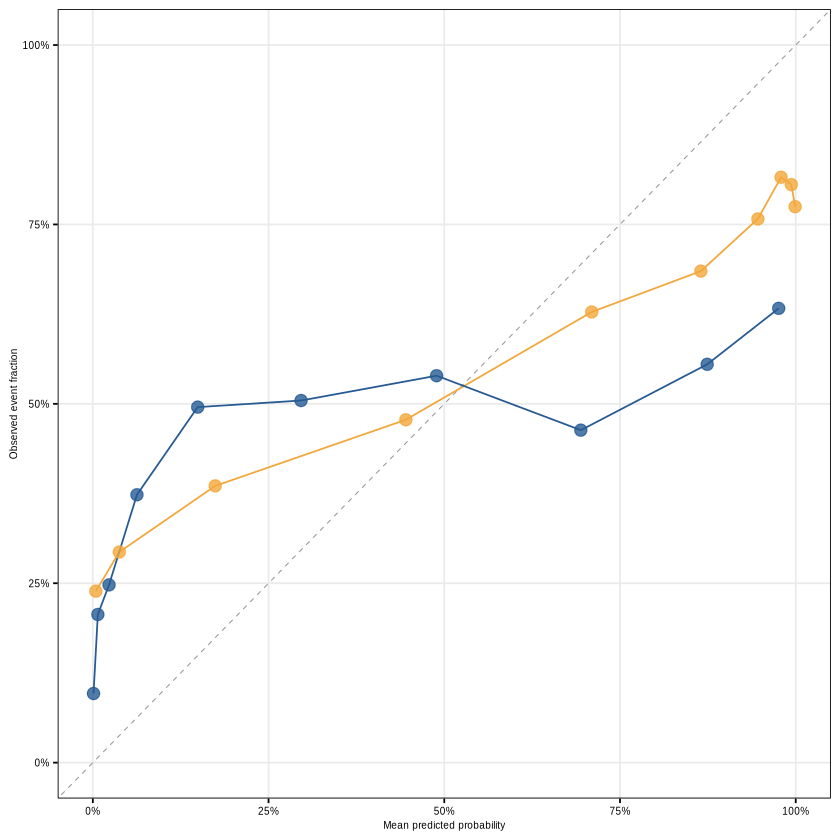

In [ ]:
suppressMessages(library(tidyverse))

## ------------------------------------------------------------------
## Pool ALL out-of-fold test predictions (raw, unaveraged) vs actual outcome,
## bin, compute observed event fraction per bin.
## ------------------------------------------------------------------

make_reliability_data <- function(scores_path, meta_path, label, pos_label, n_bins = 10) {
  scores <- read.csv(scores_path)
  meta   <- read.csv(meta_path) %>%
    select(sample_id, expGroup) %>%
    mutate(true_outcome = as.integer(expGroup == pos_label))

  pooled <- scores %>%
    filter(train_or_test == "test") %>%
    left_join(meta, by = "sample_id")

  # sanity check: flag if predicted score isn't even weakly associated with outcome
  assoc <- suppressWarnings(cor(pooled$classifier_score, pooled$true_outcome))
  message(sprintf("[%s] pos_label = '%s' | n pooled test predictions = %d | cor(score, outcome) = %.3f",
                   label, pos_label, nrow(pooled), assoc))
  if (assoc < 0) {
    warning(sprintf("[%s] cor(score, outcome) is NEGATIVE — double check pos_label='%s' is the class the classifier was trained to score toward 1.", label, pos_label))
  }

  pooled %>%
    mutate(bin = cut(classifier_score,
                      breaks = quantile(classifier_score, probs = seq(0, 1, length.out = n_bins + 1)),
                      include.lowest = TRUE, labels = FALSE)) %>%
    group_by(bin) %>%
    summarize(mean_pred = mean(classifier_score),
              obs_rate  = mean(true_outcome),
              n         = n(),
              .groups = "drop") %>%
    mutate(cohort = label)
}

## ------------------------------------------------------------------
## Brier score on the same pooled (unaveraged) predictions
## ------------------------------------------------------------------

get_brier <- function(scores_path, meta_path, pos_label) {
  scores <- read.csv(scores_path)
  meta   <- read.csv(meta_path) %>%
    select(sample_id, expGroup) %>%
    mutate(true_outcome = as.integer(expGroup == pos_label))

  pooled <- scores %>%
    filter(train_or_test == "test") %>%
    left_join(meta, by = "sample_id")
 
  mean((pooled$classifier_score - pooled$true_outcome)^2)
}

## ------------------------------------------------------------------
## Run for both cohorts
## ------------------------------------------------------------------

# NOTE: pos_label must match whichever class "y == 'Pos'" corresponded to
# when classifier_scores.csv was generated in each cohort's modeling.ipynb.
# Verify this before trusting the plot — see the cor() sanity check above.
DFCI_POS_LABEL <- "Pos"
MCC_POS_LABEL  <- "success"   # <-- confirm against modeling.ipynb's `y` definition

rel_df <- bind_rows(
  make_reliability_data(
    "../Figure4_LGVHD/modeling/classifier_scores.csv",
    "../Figure4_LGVHD/modeling/modeling_metadata.csv",
    label = "DFCI", pos_label = DFCI_POS_LABEL
  ),
  make_reliability_data(
    "../Figure5_MCCTaper/modeling/classifier_scores.csv",
    "../Figure5_MCCTaper/modeling/modeling_metadata.csv",
    label = "MCC", pos_label = MCC_POS_LABEL
  )
)

cat("Brier scores (pooled, unaveraged):\n")
cat("DFCI:", get_brier(
  "../Figure4_LGVHD/modeling/classifier_scores.csv",
  "../Figure4_LGVHD/modeling/modeling_metadata.csv",
  DFCI_POS_LABEL), "\n")
cat("MCC: ", get_brier(
  "../Figure5_MCCTaper/modeling/classifier_scores.csv",
  "../Figure5_MCCTaper/modeling/modeling_metadata.csv",
  MCC_POS_LABEL), "\n")

## ------------------------------------------------------------------
## Reliability (calibration) curve
## ------------------------------------------------------------------

COLORs_cal <- c("DFCI" = "#f2a73b", "MCC" = "#265a92")

reliability_plt <- rel_df %>%
  mutate(cohort = factor(cohort, levels = c("DFCI", "MCC"))) %>%
  ggplot(aes(x = mean_pred, y = obs_rate, color = cohort)) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "gray60", linewidth = 0.3) +
  geom_line(linewidth = 0.5) +
  geom_point(aes(size = 0.5), alpha = 0.8) +
  scale_color_manual(values = COLORs_cal) +
  scale_size_continuous(range = c(1, 4), name = "n predictions") +
  scale_x_continuous(limits = c(0, 1), labels = scales::percent_format(accuracy = 1)) +
  scale_y_continuous(limits = c(0, 1), labels = scales::percent_format(accuracy = 1)) +
  labs(x = "Mean predicted probability", y = "Observed event fraction") +
  theme_cfrna_print() +
  theme(panel.grid.minor = element_blank())

reliability_plt

WIDTH = 2.5
HEIGHT = 2

